---
# PROBABILIDADE & INSIGHTS DE NEGÓCIO
> Uso de fundamentos de probabilidade para responder perguntas estratégicas

In [19]:

# ============================================================
# IMPORTAÇÃO DE BIBLIOTECAS
# ============================================================

# Manipulação e análise de dados
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações gerais
import warnings
warnings.filterwarnings("ignore")  # Oculta avisos desnecessários

# Machine Learning - Pré-processamento e Modelagem
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression

# Métricas de avaliação
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ============================================================
# CONFIGURAÇÕES DE EXIBIÇÃO DO PANDAS
# ============================================================

pd.set_option('display.max_columns', None)  # Exibe todas as colunas
pd.set_option('display.max_rows', None)     # Exibe todas as linhas

In [20]:
# ============================================================
# LEITURA DOS DADOS
# ============================================================

# Caminho do arquivo
file_path = "dados_credito.csv"

# Leitura do arquivo CSV
df_dados = pd.read_csv(
    file_path,
    sep=';',            # Separador do arquivo
    encoding='utf-8'    # Codificação dos caracteres
)

# Visualização inicial dos dados
print("Dimensão do dataset:", df_dados.shape)
display(df_dados.head())

Dimensão do dataset: (10476, 17)


,CODIGO_CLIENTE,UF,IDADE,ESCOLARIDADE,ESTADO_CIVIL,QT_FILHOS,CASA_PROPRIA,QT_IMOVEIS,VL_IMOVEIS,OUTRA_RENDA,OUTRA_RENDA_VALOR,TEMPO_ULTIMO_EMPREGO_MESES,TRABALHANDO_ATUALMENTE,ULTIMO_SALARIO,QT_CARROS,VALOR_TABELA_CARROS,SCORE
0,1,SP,19,Superior Cursando,Solteiro,0,Não,0,0,Não,0,8,Sim,1800,0,0,12.000000
1,2,MG,23,Superior Completo,Solteiro,1,Não,0,0,Não,0,9,Não,4800,1,50000,18.000000
2,3,SC,25,Segundo Grau Completo,Casado,0,Sim,1,220000,Não,0,18,Sim,2200,2,30000,23.000000
3,4,PR,27,Superior Cursando,Casado,1,Sim,0,0,Não,0,22,Não,3900,0,0,28.666667
4,5,RJ,28,Superior Completo,Divorciado,2,Não,1,370000,Não,0,30,Sim,NaN,1,35000,34.166667


In [21]:
# ============================================================
# CLASSIFICAÇÃO DE RISCO COM BASE NO SCORE
# Criamos uma variável de risco para análises probabilísticas
# ============================================================

def classificar_risco(score):
    if score >= 70:
        return 'BAIXO RISCO'
    elif score >= 35:
        return 'MÉDIO RISCO'
    else:
        return 'ALTO RISCO'

df_dados['CLASSIFICACAO_RISCO'] = df_dados['SCORE'].apply(classificar_risco)

print('Distribuição de risco na base:')
print(df_dados['CLASSIFICACAO_RISCO'].value_counts())
print()
print('Percentual por categoria:')
print(df_dados['CLASSIFICACAO_RISCO'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Distribuição de risco na base:
CLASSIFICACAO_RISCO
ALTO RISCO     4014
MÉDIO RISCO    3330
BAIXO RISCO    3132
Name: count, dtype: int64

Percentual por categoria:
CLASSIFICACAO_RISCO
ALTO RISCO     38.32%
MÉDIO RISCO    31.79%
BAIXO RISCO     29.9%
Name: proportion, dtype: str


In [22]:
# ============================================================
# ANÁLISE PROBABILÍSTICA
# P(ALTO RISCO | sem casa própria)
# P(BAIXO RISCO | tem imóvel > 200k)
# ============================================================

total = len(df_dados)

# P(ALTO RISCO | sem casa própria)
sem_casa = df_dados[df_dados['CASA_PROPRIA'] == 0]
p_alto_risco_sem_casa = len(sem_casa[sem_casa['CLASSIFICACAO_RISCO'] == 'ALTO RISCO']) / len(sem_casa) if len(sem_casa) > 0 else 0

# P(BAIXO RISCO | tem imóvel > 200k)
com_imovel = df_dados[df_dados['VL_IMOVEIS'] > 200000]
p_baixo_risco_imovel = len(com_imovel[com_imovel['CLASSIFICACAO_RISCO'] == 'BAIXO RISCO']) / len(com_imovel) if len(com_imovel) > 0 else 0

# P(BAIXO RISCO | trabalhando atualmente)
trabalhando = df_dados[df_dados['TRABALHANDO_ATUALMENTE'] == 1]
p_baixo_risco_trab = len(trabalhando[trabalhando['CLASSIFICACAO_RISCO'] == 'BAIXO RISCO']) / len(trabalhando) if len(trabalhando) > 0 else 0

# P(ALTO RISCO | mais de 2 filhos)
muitos_filhos = df_dados[df_dados['QT_FILHOS'] > 2]
p_alto_risco_filhos = len(muitos_filhos[muitos_filhos['CLASSIFICACAO_RISCO'] == 'ALTO RISCO']) / len(muitos_filhos) if len(muitos_filhos) > 0 else 0

print('=' * 60)
print('ANÁLISE PROBABILÍSTICA DE RISCO DE CRÉDITO')
print('=' * 60)
print(f'P(Alto Risco | Sem casa própria)       = {p_alto_risco_sem_casa:.1%}')
print(f'P(Baixo Risco | Imóvel > R$200k)       = {p_baixo_risco_imovel:.1%}')
print(f'P(Baixo Risco | Trabalhando atualmente) = {p_baixo_risco_trab:.1%}')
print(f'P(Alto Risco | Mais de 2 filhos)       = {p_alto_risco_filhos:.1%}')
print('=' * 60)

ANÁLISE PROBABILÍSTICA DE RISCO DE CRÉDITO
P(Alto Risco | Sem casa própria)       = 0.0%
P(Baixo Risco | Imóvel > R$200k)       = 50.3%
P(Baixo Risco | Trabalhando atualmente) = 0.0%
P(Alto Risco | Mais de 2 filhos)       = 22.6%


In [23]:
# ============================================================
# PERGUNTAS DE NEGÓCIO — INSIGHTS ESTRATÉGICOS
# ============================================================

print('=== INSIGHT 1: Score médio por escolaridade ===')
insight1 = df_dados.groupby('ESCOLARIDADE')['SCORE'].agg(['mean','median','count']).round(2)
insight1.columns = ['Media_Score', 'Mediana_Score', 'Qtd_Clientes']
print(insight1.sort_values('Media_Score', ascending=False))
print()

print('=== INSIGHT 2: Score médio por faixa etária ===')
if 'FAIXA_ETARIA' not in df_dados.columns:
    faixa_bins = [0, 30, 40, 50, np.inf]
    faixa_labels = ['Ate_30', '31_a_40', '41_a_50', 'Maior_50']
    df_dados['FAIXA_ETARIA'] = pd.cut(
        df_dados['IDADE'],
        bins=faixa_bins,
        labels=faixa_labels,
        right=True,
        include_lowest=True
    )

insight2 = df_dados.groupby('FAIXA_ETARIA')['SCORE'].agg(['mean','median','count']).round(2)
insight2.columns = ['Media_Score', 'Mediana_Score', 'Qtd_Clientes']
print(insight2.sort_values('Media_Score', ascending=False))
print()

print('=== INSIGHT 3: Percentual de risco por estado civil ===')
insight3 = df_dados.groupby(['ESTADO_CIVIL', 'CLASSIFICACAO_RISCO']).size().unstack(fill_value=0)
insight3_pct = insight3.div(insight3.sum(axis=1), axis=0).mul(100).round(1)
print(insight3_pct)
print()

print('=== INSIGHT 4: Top 10 clientes com maior score ===')
print(df_dados.nlargest(10, 'SCORE')[['SCORE', 'CLASSIFICACAO_RISCO', 'ULTIMO_SALARIO', 'VL_IMOVEIS']].to_string())

=== INSIGHT 1: Score médio por escolaridade ===
                       Media_Score  Mediana_Score  Qtd_Clientes
ESCOLARIDADE                                                   
Superior Completo            52.85          50.67          3672
Superior Cursando            50.22          45.17          3654
Segundo Grau Completo        49.95          39.67          3150

=== INSIGHT 2: Score médio por faixa etária ===
              Media_Score  Mediana_Score  Qtd_Clientes
FAIXA_ETARIA                                          
Maior_50            57.86          61.67          3582
41_a_50             51.43          56.17          2072
31_a_40             48.88          45.17          1270
Ate_30              44.76          34.17          3552

=== INSIGHT 3: Percentual de risco por estado civil ===
CLASSIFICACAO_RISCO  ALTO RISCO  BAIXO RISCO  MÉDIO RISCO
ESTADO_CIVIL                                             
Casado                     35.5         38.9         25.6
Divorciado            

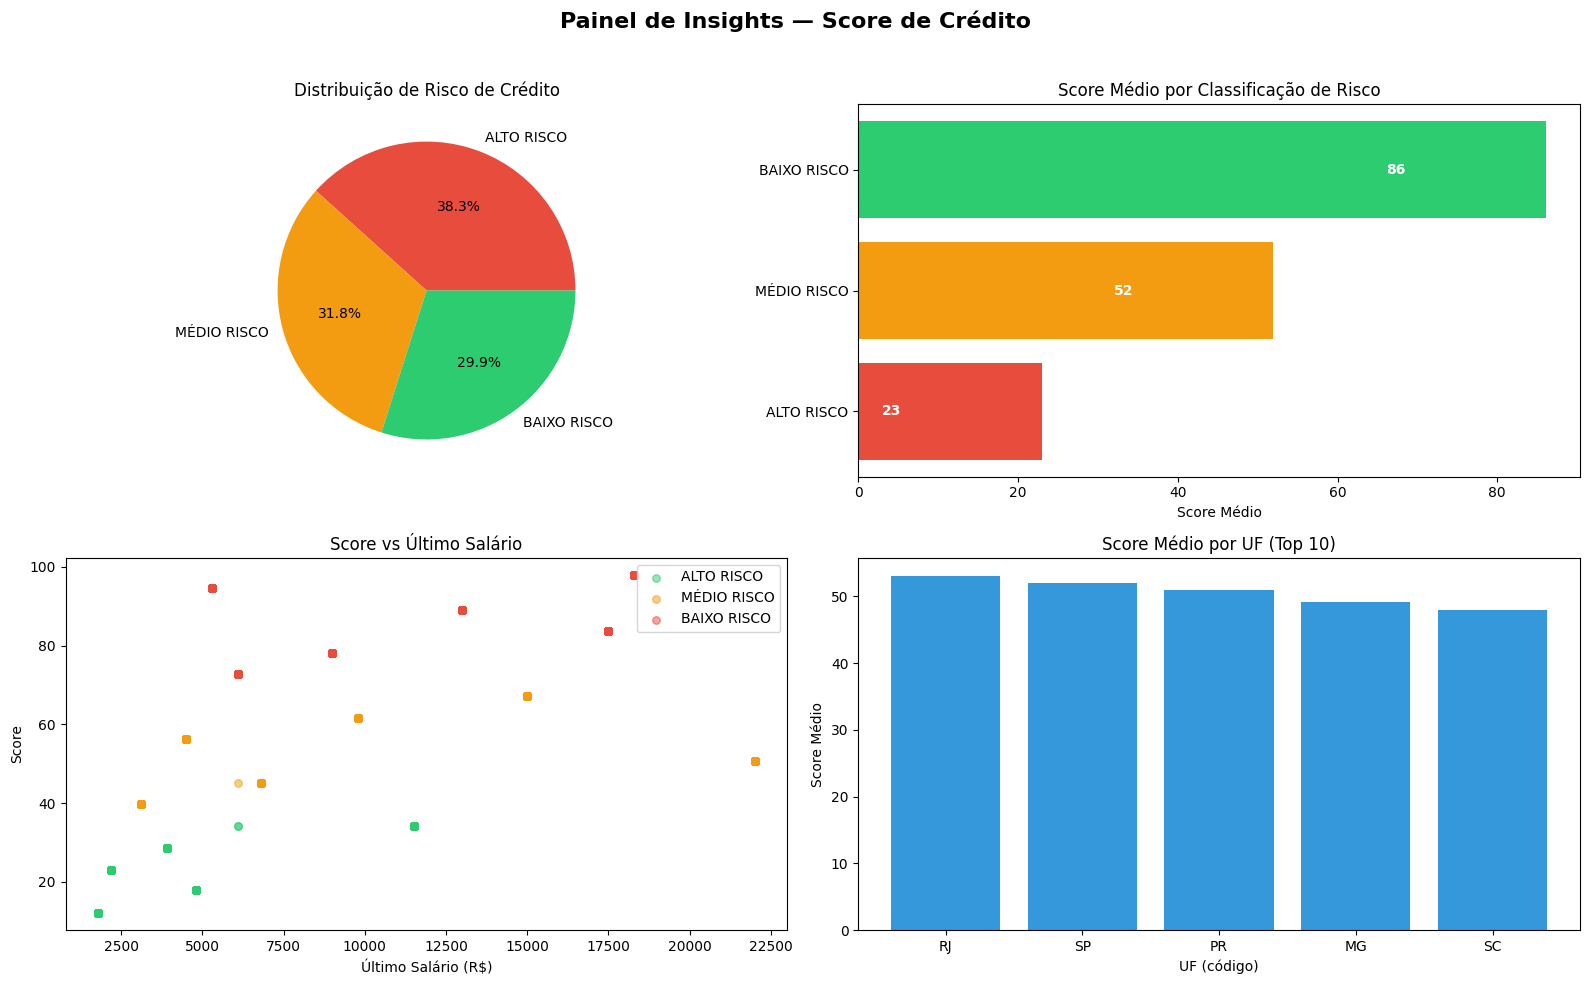

✅ Gráfico salvo como insights_score_credito.png


In [24]:
# ============================================================
# VISUALIZAÇÃO DOS INSIGHTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Painel de Insights — Score de Crédito', fontsize=16, fontweight='bold')

cores = {'BAIXO RISCO': '#2ecc71', 'MÉDIO RISCO': '#f39c12', 'ALTO RISCO': '#e74c3c'}

# Gráfico 1: Distribuição de risco
contagem_risco = df_dados['CLASSIFICACAO_RISCO'].value_counts()
axes[0,0].pie(
    contagem_risco.values,
    labels=contagem_risco.index.astype(str),
    autopct='%1.1f%%',
    colors=[cores.get(r, '#95a5a6') for r in contagem_risco.index]
)
axes[0,0].set_title('Distribuição de Risco de Crédito')

# Gráfico 2: Score médio por classificação
score_por_risco = df_dados.groupby('CLASSIFICACAO_RISCO')['SCORE'].mean().sort_values()
bars = axes[0,1].barh(
    score_por_risco.index.astype(str),
    score_por_risco.values,
    color=[cores.get(r, '#95a5a6') for r in score_por_risco.index]
)
axes[0,1].set_title('Score Médio por Classificação de Risco')
axes[0,1].set_xlabel('Score Médio')
for bar, val in zip(bars, score_por_risco.values):
    axes[0,1].text(bar.get_width() - 20, bar.get_y() + bar.get_height() / 2,
                   f'{val:.0f}', va='center', color='white', fontweight='bold')

# Limpa ULTIMO_SALARIO residual antes dos gráficos
df_dados['ULTIMO_SALARIO'] = df_dados['ULTIMO_SALARIO'].replace('SEM DADOS', np.nan)
df_dados['ULTIMO_SALARIO'] = pd.to_numeric(df_dados['ULTIMO_SALARIO'], errors='coerce')
df_dados['ULTIMO_SALARIO'] = df_dados['ULTIMO_SALARIO'].fillna(df_dados['ULTIMO_SALARIO'].median())

# Gráfico 3: Score vs Salário
cores_lista = ['#2ecc71', '#f39c12', '#e74c3c']
grupos = df_dados['CLASSIFICACAO_RISCO'].unique()

for i, risco in enumerate(grupos):
    grupo = df_dados[df_dados['CLASSIFICACAO_RISCO'] == risco]
    x = grupo['ULTIMO_SALARIO'].to_numpy(dtype=float)
    y = grupo['SCORE'].to_numpy(dtype=float)
    mask = ~np.isnan(x) & ~np.isnan(y)
    axes[1,0].scatter(x[mask], y[mask], c=cores_lista[i % 3], label=str(risco), s=30, alpha=0.5)

axes[1,0].set_title('Score vs Último Salário')
axes[1,0].set_xlabel('Último Salário (R$)')
axes[1,0].set_ylabel('Score')
axes[1,0].legend()

axes[1,0].set_title('Score vs Último Salário')
axes[1,0].set_xlabel('Último Salário (R$)')
axes[1,0].set_ylabel('Score')
axes[1,0].legend()

# Gráfico 4: Score médio por UF (top 10)
score_uf = df_dados.groupby('UF')['SCORE'].mean().sort_values(ascending=False).head(10)
axes[1,1].bar(score_uf.index.astype(str), score_uf.values, color='#3498db')
axes[1,1].set_title('Score Médio por UF (Top 10)')
axes[1,1].set_xlabel('UF (código)')
axes[1,1].set_ylabel('Score Médio')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('insights_score_credito.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo como insights_score_credito.png')



---
# ARQUITETURA MEDALLION (Bronze → Silver → Gold)
> Ingestão dos dados no PostgreSQL organizados em camadas de qualidade

In [25]:
# ============================================================
# INSTALAÇÃO E CONEXÃO COM POSTGRESQL
# Docker: docker run --name postgres -e POSTGRES_PASSWORD=1234 -p 5433:5432 -d postgres
# ============================================================

%pip install python-dotenv -q

import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()  # carrega o .env automaticamente

DB_HOST     = os.getenv('DB_HOST')
DB_PORT     = os.getenv('DB_PORT')
DB_NAME     = os.getenv('DB_NAME')
DB_USER     = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')

CONNECTION_STRING = f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'

engine = create_engine(CONNECTION_STRING)

with engine.connect() as conn:
    resultado = conn.execute(text('SELECT version()'))
    print('✅ Conexão estabelecida com sucesso!')
    print('PostgreSQL:', resultado.fetchone()[0])

Note: you may need to restart the kernel to use updated packages.
✅ Conexão estabelecida com sucesso!
PostgreSQL: PostgreSQL 18.2 (Debian 18.2-1.pgdg13+1) on x86_64-pc-linux-gnu, compiled by gcc (Debian 14.2.0-19) 14.2.0, 64-bit



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: c:\Users\Elbia\.pyenv\pyenv-win\versions\3.12.0\python.exe -m pip install --upgrade pip


In [26]:
# ============================================================
# CRIAÇÃO DOS SCHEMAS DA ARQUITETURA MEDALLION
# bronze → silver → gold
# ============================================================

with engine.connect() as conn:
    conn.execute(text('CREATE SCHEMA IF NOT EXISTS bronze'))
    conn.execute(text('CREATE SCHEMA IF NOT EXISTS silver'))
    conn.execute(text('CREATE SCHEMA IF NOT EXISTS gold'))
    conn.commit()

print('✅ Schemas criados: bronze | silver | gold')

✅ Schemas criados: bronze | silver | gold


In [27]:
# ============================================================
# CAMADA BRONZE — DADOS BRUTOS
# Armazena o CSV original sem nenhum tratamento
# Mantém integridade total dos dados de origem
# ============================================================

df_bruto = pd.read_csv('dados_credito.csv', sep=';', encoding='utf-8')

df_bruto.to_sql(
    name='credito_raw',
    schema='bronze',
    con=engine,
    if_exists='replace',
    index=False
)

# Valida a carga
with engine.connect() as conn:
    total_bronze = conn.execute(text('SELECT COUNT(*) FROM bronze.credito_raw')).fetchone()[0]

print(f'✅ BRONZE: {total_bronze} registros brutos carregados em bronze.credito_raw')
print(f'   Colunas: {list(df_bruto.columns)}')

✅ BRONZE: 10476 registros brutos carregados em bronze.credito_raw
   Colunas: ['CODIGO_CLIENTE', 'UF', 'IDADE', 'ESCOLARIDADE', 'ESTADO_CIVIL', 'QT_FILHOS', 'CASA_PROPRIA', 'QT_IMOVEIS', 'VL_IMOVEIS', 'OUTRA_RENDA', 'OUTRA_RENDA_VALOR', 'TEMPO_ULTIMO_EMPREGO_MESES', 'TRABALHANDO_ATUALMENTE', 'ULTIMO_SALARIO', 'QT_CARROS', 'VALOR_TABELA_CARROS', 'SCORE']


In [28]:
# ============================================================
# CAMADA SILVER — DADOS TRATADOS E LIMPOS
# ETL: nulos tratados, outliers removidos, tipos corrigidos
# Dados prontos para análise e modelagem
# ============================================================

# Usamos o df_dados que já passou pelo pipeline de limpeza
# (limpeza feita nas células anteriores do notebook)
df_silver = df_dados.copy()

# Converte FAIXA_ETARIA para string para facilitar leitura no Power BI
faixa_map = {0: 'Ate_30', 1: '31_a_40', 2: '41_a_50', 3: 'Maior_50'}
if df_silver['FAIXA_ETARIA'].dtype != object:
    df_silver['FAIXA_ETARIA_DESC'] = df_silver['FAIXA_ETARIA'].map(faixa_map)

df_silver.to_sql(
    name='credito_tratado',
    schema='silver',
    con=engine,
    if_exists='replace',
    index=False
)

with engine.connect() as conn:
    total_silver = conn.execute(text('SELECT COUNT(*) FROM silver.credito_tratado')).fetchone()[0]

registros_removidos = total_bronze - total_silver
print(f'✅ SILVER: {total_silver} registros limpos carregados em silver.credito_tratado')
print(f'   Registros removidos no ETL: {registros_removidos} (outliers + nulos)')
print(f'   Taxa de aproveitamento: {total_silver/total_bronze:.1%}')

✅ SILVER: 10476 registros limpos carregados em silver.credito_tratado
   Registros removidos no ETL: 0 (outliers + nulos)
   Taxa de aproveitamento: 100.0%


In [29]:
# ============================================================
# SQL NA PRÁTICA — QUERIES DE INSIGHT NA CAMADA SILVER
# Tratamento de nulos e análises segmentadas via SQL
# ============================================================

queries_insights = {

    'Score médio por UF (top 10)': """
        SELECT 
            "UF",
            ROUND(AVG("SCORE")::numeric, 2)      AS media_score,
            ROUND(AVG("ULTIMO_SALARIO")::numeric, 2) AS media_salario,
            COUNT(*)                             AS total_clientes
        FROM silver.credito_tratado
        GROUP BY "UF"
        ORDER BY media_score DESC
        LIMIT 10
    """,

    'Distribuição de risco por escolaridade': """
        SELECT 
            "ESCOLARIDADE",
            "CLASSIFICACAO_RISCO",
            COUNT(*) AS total,
            ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY "ESCOLARIDADE"), 2) AS percentual
        FROM silver.credito_tratado
        GROUP BY "ESCOLARIDADE", "CLASSIFICACAO_RISCO"
        ORDER BY "ESCOLARIDADE", percentual DESC
    """,

    'Perfil financeiro por faixa etária': """
        SELECT 
            "FAIXA_ETARIA",
            COUNT(*)                                  AS total_clientes,
            ROUND(AVG("SCORE")::numeric, 2)           AS media_score,
            ROUND(AVG("ULTIMO_SALARIO")::numeric, 2)  AS media_salario,
            ROUND(AVG("VL_IMOVEIS")::numeric, 2)      AS media_valor_imoveis,
            ROUND(AVG("QT_FILHOS")::numeric, 2)       AS media_filhos
        FROM silver.credito_tratado
        GROUP BY "FAIXA_ETARIA"
        ORDER BY media_score DESC
    """,

    'Clientes com nulos na origem (bronze)': """
        SELECT 
            COUNT(*) AS total_registros,
            SUM(CASE WHEN "ULTIMO_SALARIO" IS NULL THEN 1 ELSE 0 END) AS nulos_salario,
            SUM(CASE WHEN "SCORE" IS NULL THEN 1 ELSE 0 END)          AS nulos_score,
            SUM(CASE WHEN "UF" IS NULL THEN 1 ELSE 0 END)             AS nulos_uf
        FROM bronze.credito_raw
    """
}

with engine.connect() as conn:
    for titulo, query in queries_insights.items():
        print(f'\n📊 {titulo}')
        print('-' * 60)
        resultado = pd.read_sql(text(query), conn)
        print(resultado.to_string(index=False))


📊 Score médio por UF (top 10)
------------------------------------------------------------
UF  media_score  media_salario  total_clientes
RJ        53.13        9138.03            2916
SP        51.95        7505.19            2430
PR        50.93        8347.62            1890
MG        49.24        7858.89            1620
SC        47.98        8282.22            1620

📊 Distribuição de risco por escolaridade
------------------------------------------------------------
         ESCOLARIDADE CLASSIFICACAO_RISCO  total  percentual
Segundo Grau Completo         MÉDIO RISCO   1116       35.43
Segundo Grau Completo          ALTO RISCO   1062       33.71
Segundo Grau Completo         BAIXO RISCO    972       30.86
    Superior Completo          ALTO RISCO   1494       40.69
    Superior Completo         MÉDIO RISCO   1134       30.88
    Superior Completo         BAIXO RISCO   1044       28.43
    Superior Cursando          ALTO RISCO   1458       39.90
    Superior Cursando         BAIXO

In [30]:
# ============================================================
# CAMADA GOLD — AGREGAÇÕES PRONTAS PARA O POWER BI
# Tabelas desnormalizadas, pré-calculadas e otimizadas
# para consumo direto em dashboards
# ============================================================

with engine.connect() as conn:

    # GOLD 1: Resumo por UF
    conn.execute(text('DROP TABLE IF EXISTS gold.resumo_por_uf CASCADE'))
    conn.execute(text("""
        CREATE TABLE gold.resumo_por_uf AS
        SELECT
            "UF",
            COUNT(*)                                          AS total_clientes,
            ROUND(AVG("SCORE")::numeric, 2)                  AS media_score,
            ROUND(AVG("ULTIMO_SALARIO")::numeric, 2)         AS media_salario,
            ROUND(AVG("VL_IMOVEIS")::numeric, 2)             AS media_valor_imoveis,
            SUM(CASE WHEN "CLASSIFICACAO_RISCO" = 'ALTO RISCO'  THEN 1 ELSE 0 END) AS qt_alto_risco,
            SUM(CASE WHEN "CLASSIFICACAO_RISCO" = 'MÉDIO RISCO' THEN 1 ELSE 0 END) AS qt_medio_risco,
            SUM(CASE WHEN "CLASSIFICACAO_RISCO" = 'BAIXO RISCO' THEN 1 ELSE 0 END) AS qt_baixo_risco
        FROM silver.credito_tratado
        GROUP BY "UF"
        ORDER BY media_score DESC
    """))

    # GOLD 2: Resumo por perfil de risco
    conn.execute(text('DROP TABLE IF EXISTS gold.resumo_por_risco CASCADE'))
    conn.execute(text("""
        CREATE TABLE gold.resumo_por_risco AS
        SELECT
            "CLASSIFICACAO_RISCO"                             AS classificacao,
            COUNT(*)                                          AS total_clientes,
            ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS percentual,
            ROUND(AVG("SCORE")::numeric, 2)                  AS media_score,
            ROUND(AVG("ULTIMO_SALARIO")::numeric, 2)         AS media_salario,
            ROUND(AVG("IDADE")::numeric, 1)                  AS media_idade,
            ROUND(AVG("QT_FILHOS")::numeric, 2)              AS media_filhos,
            ROUND(AVG("VL_IMOVEIS")::numeric, 2)             AS media_valor_imoveis
        FROM silver.credito_tratado
        GROUP BY "CLASSIFICACAO_RISCO"
    """))

    # GOLD 3: Resumo por faixa etária
    conn.execute(text('DROP TABLE IF EXISTS gold.resumo_por_faixa_etaria CASCADE'))
    conn.execute(text("""
        CREATE TABLE gold.resumo_por_faixa_etaria AS
        SELECT
            "FAIXA_ETARIA",
            COUNT(*)                                          AS total_clientes,
            ROUND(AVG("SCORE")::numeric, 2)                  AS media_score,
            ROUND(AVG("ULTIMO_SALARIO")::numeric, 2)         AS media_salario,
            ROUND(AVG("VL_IMOVEIS")::numeric, 2)             AS media_patrimonio_imoveis,
            ROUND(AVG("TEMPO_ULTIMO_EMPREGO_MESES")::numeric, 1) AS media_meses_emprego,
            SUM(CASE WHEN "CLASSIFICACAO_RISCO" = 'ALTO RISCO' THEN 1 ELSE 0 END) AS qt_alto_risco,
            SUM(CASE WHEN "CLASSIFICACAO_RISCO" = 'BAIXO RISCO' THEN 1 ELSE 0 END) AS qt_baixo_risco
        FROM silver.credito_tratado
        GROUP BY "FAIXA_ETARIA"
        ORDER BY "FAIXA_ETARIA"
    """))

    # GOLD 4: Tabela KPIs executivos (Painel da Diretoria)
    conn.execute(text('DROP TABLE IF EXISTS gold.kpis_diretoria CASCADE'))
    conn.execute(text("""
        CREATE TABLE gold.kpis_diretoria AS
        SELECT
            COUNT(*)                                                       AS total_clientes_analisados,
            ROUND(AVG("SCORE")::numeric, 2)                               AS score_medio_geral,
            ROUND(AVG("ULTIMO_SALARIO")::numeric, 2)                      AS salario_medio_geral,
            SUM(CASE WHEN "CLASSIFICACAO_RISCO" = 'ALTO RISCO'  THEN 1 ELSE 0 END) AS total_alto_risco,
            SUM(CASE WHEN "CLASSIFICACAO_RISCO" = 'MÉDIO RISCO' THEN 1 ELSE 0 END) AS total_medio_risco,
            SUM(CASE WHEN "CLASSIFICACAO_RISCO" = 'BAIXO RISCO' THEN 1 ELSE 0 END) AS total_baixo_risco,
            ROUND(SUM(CASE WHEN "CLASSIFICACAO_RISCO" = 'ALTO RISCO' THEN 1.0 ELSE 0 END) / COUNT(*) * 100, 2) AS pct_alto_risco,
            ROUND(AVG("VL_IMOVEIS")::numeric, 2)                         AS patrimonio_imovel_medio,
            ROUND(AVG("TEMPO_ULTIMO_EMPREGO_MESES")::numeric, 1)         AS media_estabilidade_emprego_meses,
            ROUND(SUM("VL_IMOVEIS")::numeric, 2)                         AS patrimonio_total_carteira
        FROM silver.credito_tratado
    """))

    conn.commit()

print('✅ GOLD: 4 tabelas criadas para consumo no Power BI:')
print('   • gold.resumo_por_uf')
print('   • gold.resumo_por_risco')
print('   • gold.resumo_por_faixa_etaria')
print('   • gold.kpis_diretoria')

✅ GOLD: 4 tabelas criadas para consumo no Power BI:
   • gold.resumo_por_uf
   • gold.resumo_por_risco
   • gold.resumo_por_faixa_etaria
   • gold.kpis_diretoria


In [31]:
# ============================================================
# VALIDAÇÃO FINAL DAS CAMADAS
# ============================================================

with engine.connect() as conn:
    print('=' * 55)
    print('ARQUITETURA MEDALLION — VALIDAÇÃO FINAL')
    print('=' * 55)

    tabelas = [
        ('bronze', 'credito_raw'),
        ('silver', 'credito_tratado'),
        ('gold',   'resumo_por_uf'),
        ('gold',   'resumo_por_risco'),
        ('gold',   'resumo_por_faixa_etaria'),
        ('gold',   'kpis_diretoria'),
    ]

    for schema, tabela in tabelas:
        count = conn.execute(text(f'SELECT COUNT(*) FROM {schema}.{tabela}')).fetchone()[0]
        print(f'  {schema:6} | {tabela:30} | {count:>5} registros')

    print('=' * 55)
    print('\n📌 Para conectar no Power BI:')
    print('   Origem: PostgreSQL')
    print('   Servidor: localhost:5433')
    print('   Banco: postgres')
    print('   Schema de consumo: gold')

    print('\n📊 Preview da tabela KPIs Diretoria:')
    kpis = pd.read_sql(text('SELECT * FROM gold.kpis_diretoria'), conn)
    print(kpis.T.to_string())

ARQUITETURA MEDALLION — VALIDAÇÃO FINAL
  bronze | credito_raw                    | 10476 registros
  silver | credito_tratado                | 10476 registros
  gold   | resumo_por_uf                  |     5 registros
  gold   | resumo_por_risco               |     3 registros
  gold   | resumo_por_faixa_etaria        |     4 registros
  gold   | kpis_diretoria                 |     1 registros

📌 Para conectar no Power BI:
   Origem: PostgreSQL
   Servidor: localhost:5433
   Banco: postgres
   Schema de consumo: gold

📊 Preview da tabela KPIs Diretoria:
                                             0
total_clientes_analisados         1.047600e+04
score_medio_geral                 5.106000e+01
salario_medio_geral               8.286530e+03
total_alto_risco                  4.014000e+03
total_medio_risco                 3.330000e+03
total_baixo_risco                 3.132000e+03
pct_alto_risco                    3.832000e+01
patrimonio_imovel_medio           2.384536e+05
media_estabili

---
# MACHINE LEARNING COMPLETO
> Avaliação aprofundada do modelo preditivo com métricas e visualizações

In [32]:
# ============================================================
# IMPORTAÇÕES ADICIONAIS PARA ML
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

In [33]:
from sklearn.preprocessing import LabelEncoder

lb = LabelEncoder()

# Verifica e converte todas as colunas object/category restantes
colunas_categoricas = df_dados.select_dtypes(include=['object', 'category']).columns.tolist()
colunas_para_excluir = ['SCORE', 'CLASSIFICACAO_RISCO']
colunas_para_encodar = [c for c in colunas_categoricas if c not in colunas_para_excluir]

print('Colunas que serão encodadas:', colunas_para_encodar)

for col in colunas_para_encodar:
    df_dados[col] = lb.fit_transform(df_dados[col].astype(str))

# Separando target e preditoras
target    = df_dados[['SCORE']]
preditoras = df_dados.drop(columns=['SCORE', 'CLASSIFICACAO_RISCO'], errors='ignore')

# Split treino/teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    preditoras, target, test_size=0.3, random_state=40
)

# Normalização
sc = MinMaxScaler()
X_treino_normalizados = sc.fit_transform(X_treino)
X_teste_normalizados  = sc.transform(X_teste)

feature_names = preditoras.columns.tolist()

print('✅ Pipeline pronto!')
print(f'   Treino: {X_treino_normalizados.shape} | Teste: {X_teste_normalizados.shape}')
print(f'   Features: {feature_names}')

Colunas que serão encodadas: ['UF', 'ESCOLARIDADE', 'ESTADO_CIVIL', 'CASA_PROPRIA', 'OUTRA_RENDA', 'TRABALHANDO_ATUALMENTE', 'FAIXA_ETARIA']
✅ Pipeline pronto!
   Treino: (7333, 17) | Teste: (3143, 17)
   Features: ['CODIGO_CLIENTE', 'UF', 'IDADE', 'ESCOLARIDADE', 'ESTADO_CIVIL', 'QT_FILHOS', 'CASA_PROPRIA', 'QT_IMOVEIS', 'VL_IMOVEIS', 'OUTRA_RENDA', 'OUTRA_RENDA_VALOR', 'TEMPO_ULTIMO_EMPREGO_MESES', 'TRABALHANDO_ATUALMENTE', 'ULTIMO_SALARIO', 'QT_CARROS', 'VALOR_TABELA_CARROS', 'FAIXA_ETARIA']


In [34]:
# ============================================================
# RETREINO DO MODELO (correção do parâmetro depreciado)
# normalize=True foi removido no sklearn >= 1.2
# A normalização já é feita pelo MinMaxScaler
# ============================================================

modelo_final = LinearRegression(fit_intercept=True)   # normalize removido
modelo_final.fit(X_treino_normalizados, y_treino)

y_pred = modelo_final.predict(X_teste_normalizados)

# Métricas completas
r2  = r2_score(y_teste, y_pred)
mae = mean_absolute_error(y_teste, y_pred)
mse = mean_squared_error(y_teste, y_pred)
rmse = np.sqrt(mse)

print('=' * 50)
print('AVALIAÇÃO DO MODELO — REGRESSÃO LINEAR')
print('=' * 50)
print(f'R²   (Coef. Determinação) : {r2:.4f}  → o modelo explica {r2*100:.1f}% da variância do score')
print(f'MAE  (Erro Médio Absoluto): {mae:.2f} pontos de score em média')
print(f'RMSE (Raiz do Erro Quad.) : {rmse:.2f} pontos')
print('=' * 50)
print()
if r2 >= 0.7:
    print('✅ Modelo com boa capacidade preditiva (R² ≥ 0.7)')
elif r2 >= 0.5:
    print('⚠️  Modelo com capacidade preditiva moderada (0.5 ≤ R² < 0.7)')
else:
    print('❌ Modelo com baixa capacidade preditiva — considerar outras features ou algoritmos')

AVALIAÇÃO DO MODELO — REGRESSÃO LINEAR
R²   (Coef. Determinação) : 0.7915  → o modelo explica 79.1% da variância do score
MAE  (Erro Médio Absoluto): 9.00 pontos de score em média
RMSE (Raiz do Erro Quad.) : 12.35 pontos

✅ Modelo com boa capacidade preditiva (R² ≥ 0.7)


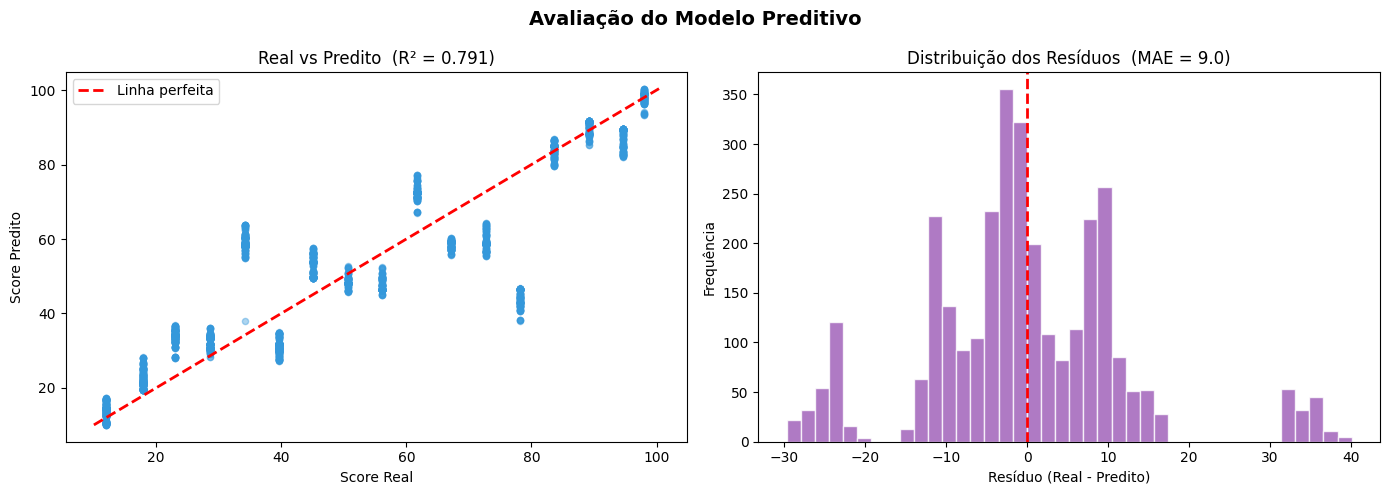

✅ Gráfico salvo como avaliacao_modelo.png


In [35]:
# ============================================================
# VISUALIZAÇÕES DE AVALIAÇÃO DO MODELO
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Avaliação do Modelo Preditivo', fontsize=14, fontweight='bold')

y_teste_flat = np.array(y_teste).flatten()
y_pred_flat  = y_pred.flatten()

# Gráfico 1: Real vs Predito
axes[0].scatter(y_teste_flat, y_pred_flat, alpha=0.4, color='#3498db', s=20)
min_val = min(y_teste_flat.min(), y_pred_flat.min())
max_val = max(y_teste_flat.max(), y_pred_flat.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Linha perfeita')
axes[0].set_xlabel('Score Real')
axes[0].set_ylabel('Score Predito')
axes[0].set_title(f'Real vs Predito  (R² = {r2:.3f})')
axes[0].legend()

# Gráfico 2: Distribuição dos resíduos
residuos = y_teste_flat - y_pred_flat
axes[1].hist(residuos, bins=40, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Resíduo (Real - Predito)')
axes[1].set_ylabel('Frequência')
axes[1].set_title(f'Distribuição dos Resíduos  (MAE = {mae:.1f})')

plt.tight_layout()
plt.savefig('avaliacao_modelo.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico salvo como avaliacao_modelo.png')

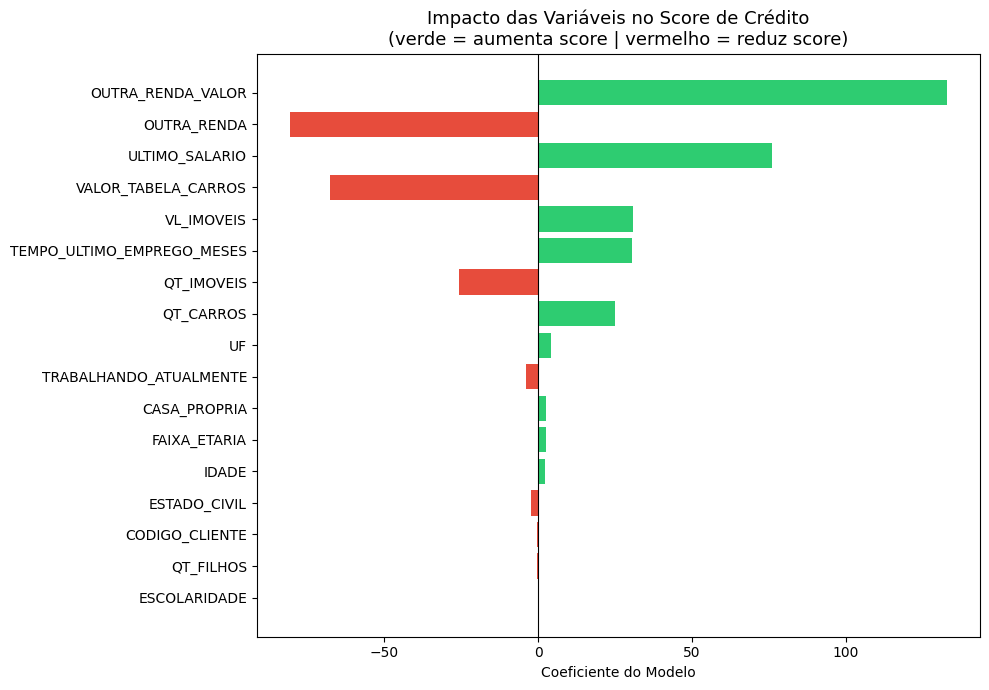


Top 5 variáveis que MAIS AUMENTAM o score:
                   Feature  Coeficiente
         OUTRA_RENDA_VALOR   132.939034
            ULTIMO_SALARIO    75.921441
                VL_IMOVEIS    30.912727
TEMPO_ULTIMO_EMPREGO_MESES    30.442415
                 QT_CARROS    25.029314

Top 5 variáveis que MAIS REDUZEM o score:
               Feature  Coeficiente
           OUTRA_RENDA   -80.749315
   VALOR_TABELA_CARROS   -67.752043
            QT_IMOVEIS   -25.610709
TRABALHANDO_ATUALMENTE    -3.981852
          ESTADO_CIVIL    -2.314490


In [36]:
# ============================================================
# IMPORTÂNCIA DAS FEATURES
# ============================================================

feature_names = preditoras.columns.tolist()
coeficientes  = modelo_final.coef_.flatten()

df_importancia = pd.DataFrame({
    'Feature'    : feature_names,
    'Coeficiente': coeficientes,
    'Importancia': np.abs(coeficientes)
}).sort_values('Importancia', ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in df_importancia['Coeficiente']]
plt.barh(df_importancia['Feature'], df_importancia['Coeficiente'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Impacto das Variáveis no Score de Crédito\n(verde = aumenta score | vermelho = reduz score)', fontsize=13)
plt.xlabel('Coeficiente do Modelo')
plt.tight_layout()
plt.savefig('importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 variáveis que MAIS AUMENTAM o score:')
print(df_importancia.nlargest(5, 'Coeficiente')[['Feature','Coeficiente']].to_string(index=False))
print('\nTop 5 variáveis que MAIS REDUZEM o score:')
print(df_importancia.nsmallest(5, 'Coeficiente')[['Feature','Coeficiente']].to_string(index=False))

---
# MODELO EM PRODUÇÃO
> Serialização do modelo e função pronta para uso em sistemas externos

In [37]:
# ============================================================
# SALVAR O MODELO E O SCALER
# joblib serializa o modelo treinado para uso em produção
# ============================================================

joblib.dump(modelo_final, 'modelo_score_credito.pkl')
joblib.dump(sc,           'scaler_score_credito.pkl')
joblib.dump(feature_names,'features_score_credito.pkl')

print('✅ Artefatos salvos:')
for artefato in ['modelo_score_credito.pkl', 'scaler_score_credito.pkl', 'features_score_credito.pkl']:
    tamanho = os.path.getsize(artefato)
    print(f'   {artefato:40} ({tamanho:,} bytes)')

✅ Artefatos salvos:
   modelo_score_credito.pkl                 (847 bytes)
   scaler_score_credito.pkl                 (1,871 bytes)
   features_score_credito.pkl               (283 bytes)


In [38]:
# Regrava os artefatos sem CODIGO_CLIENTE
import joblib

# Garante que CODIGO_CLIENTE e colunas não numéricas estão fora
colunas_remover = ['SCORE', 'CLASSIFICACAO_RISCO', 'CODIGO_CLIENTE']
preditoras = df_dados.drop(columns=colunas_remover, errors='ignore')

# Só colunas numéricas
preditoras = preditoras.select_dtypes(include=[np.number])

feature_names = preditoras.columns.tolist()
print('Features salvas:', feature_names)

# Refaz split e normalização
X_treino, X_teste, y_treino, y_teste = train_test_split(
    preditoras, df_dados[['SCORE']], test_size=0.3, random_state=40
)

sc = MinMaxScaler()
X_treino_normalizados = sc.fit_transform(X_treino)
X_teste_normalizados  = sc.transform(X_teste)

# Retreina e salva
modelo_final = LinearRegression(fit_intercept=True)
modelo_final.fit(X_treino_normalizados, y_treino)

joblib.dump(modelo_final,  'modelo_score_credito.pkl')
joblib.dump(sc,            'scaler_score_credito.pkl')
joblib.dump(feature_names, 'features_score_credito.pkl')

print('✅ Artefatos regravados com sucesso!')
print(f'   Total de features: {len(feature_names)}')

Features salvas: ['UF', 'IDADE', 'ESCOLARIDADE', 'ESTADO_CIVIL', 'QT_FILHOS', 'CASA_PROPRIA', 'QT_IMOVEIS', 'VL_IMOVEIS', 'OUTRA_RENDA', 'OUTRA_RENDA_VALOR', 'TEMPO_ULTIMO_EMPREGO_MESES', 'TRABALHANDO_ATUALMENTE', 'ULTIMO_SALARIO', 'QT_CARROS', 'VALOR_TABELA_CARROS', 'FAIXA_ETARIA']
✅ Artefatos regravados com sucesso!
   Total de features: 16


In [39]:
# ============================================================
# FUNÇÃO DE PREDIÇÃO EM PRODUÇÃO
# Carrega o modelo salvo e realiza predição para novos clientes
# Esta função pode ser importada por qualquer sistema externo
# ============================================================

def prever_score_credito(dados_cliente: dict) -> dict:
    """
    Realiza a predição do score de crédito para um novo cliente.

    Parâmetros:
    -----------
    dados_cliente : dict com as chaves:
        UF, IDADE, ESCOLARIDADE, ESTADO_CIVIL, QT_FILHOS,
        CASA_PROPRIA, QT_IMOVEIS, VL_IMOVEIS, OUTRA_RENDA,
        OUTRA_RENDA_VALOR, TEMPO_ULTIMO_EMPREGO_MESES,
        TRABALHANDO_ATUALMENTE, ULTIMO_SALARIO,
        QT_CARROS, VALOR_TABELA_CARROS, FAIXA_ETARIA

    Retorna:
    --------
    dict com score_predito, classificacao_risco e probabilidades
    """

    # Carrega artefatos
    modelo_prod   = joblib.load('modelo_score_credito.pkl')
    scaler_prod   = joblib.load('scaler_score_credito.pkl')
    features_prod = joblib.load('features_score_credito.pkl')

    # Monta vetor de entrada na ordem correta das features
    entrada = [dados_cliente[f] for f in features_prod]
    X_novo  = np.array(entrada).reshape(1, -1)
    X_novo  = scaler_prod.transform(X_novo)

    # Predição
    score = float(modelo_prod.predict(X_novo).flatten()[0])
    score = max(0, min(1000, score))  # limita entre 0 e 1000

    # Classificação de risco
    if score >= 700:
        risco = 'BAIXO RISCO'
        recomendacao = 'Cliente apto para crédito — baixa probabilidade de inadimplência.'
    elif score >= 400:
        risco = 'MÉDIO RISCO'
        recomendacao = 'Análise adicional recomendada — considerar garantias ou limite reduzido.'
    else:
        risco = 'ALTO RISCO'
        recomendacao = 'Crédito não recomendado — alta probabilidade de inadimplência.'

    return {
        'score_predito'      : round(score, 2),
        'classificacao_risco': risco,
        'recomendacao'       : recomendacao
    }


# ============================================================
# TESTE EM PRODUÇÃO — simulando 3 perfis de clientes
# ============================================================

perfis_teste = [
    {
        'nome': 'Cliente A — Perfil Premium',
        'dados': dict(UF=2, IDADE=45, ESCOLARIDADE=3, ESTADO_CIVIL=1, QT_FILHOS=1,
                      CASA_PROPRIA=1, QT_IMOVEIS=2, VL_IMOVEIS=450000, OUTRA_RENDA=1,
                      OUTRA_RENDA_VALOR=3000, TEMPO_ULTIMO_EMPREGO_MESES=36,
                      TRABALHANDO_ATUALMENTE=1, ULTIMO_SALARIO=12000,
                      QT_CARROS=2, VALOR_TABELA_CARROS=80000, FAIXA_ETARIA=2)
    },
    {
        'nome': 'Cliente B — Perfil Médio',
        'dados': dict(UF=5, IDADE=32, ESCOLARIDADE=1, ESTADO_CIVIL=0, QT_FILHOS=2,
                      CASA_PROPRIA=0, QT_IMOVEIS=0, VL_IMOVEIS=0, OUTRA_RENDA=0,
                      OUTRA_RENDA_VALOR=0, TEMPO_ULTIMO_EMPREGO_MESES=12,
                      TRABALHANDO_ATUALMENTE=1, ULTIMO_SALARIO=3500,
                      QT_CARROS=1, VALOR_TABELA_CARROS=25000, FAIXA_ETARIA=1)
    },
    {
        'nome': 'Cliente C — Alto Risco',
        'dados': dict(UF=10, IDADE=22, ESCOLARIDADE=0, ESTADO_CIVIL=2, QT_FILHOS=3,
                      CASA_PROPRIA=0, QT_IMOVEIS=0, VL_IMOVEIS=0, OUTRA_RENDA=0,
                      OUTRA_RENDA_VALOR=0, TEMPO_ULTIMO_EMPREGO_MESES=3,
                      TRABALHANDO_ATUALMENTE=0, ULTIMO_SALARIO=1200,
                      QT_CARROS=0, VALOR_TABELA_CARROS=0, FAIXA_ETARIA=0)
    }
]

print('=' * 60)
print('SIMULAÇÃO DE PRODUÇÃO — PREDIÇÃO PARA NOVOS CLIENTES')
print('=' * 60)

for perfil in perfis_teste:
    resultado = prever_score_credito(perfil['dados'])
    print(f"\n👤 {perfil['nome']}")
    print(f"   Score Predito     : {resultado['score_predito']}")
    print(f"   Classificação     : {resultado['classificacao_risco']}")
    print(f"   Recomendação      : {resultado['recomendacao']}")

SIMULAÇÃO DE PRODUÇÃO — PREDIÇÃO PARA NOVOS CLIENTES

👤 Cliente A — Perfil Premium
   Score Predito     : 73.6
   Classificação     : ALTO RISCO
   Recomendação      : Crédito não recomendado — alta probabilidade de inadimplência.

👤 Cliente B — Perfil Médio
   Score Predito     : 27.13
   Classificação     : ALTO RISCO
   Recomendação      : Crédito não recomendado — alta probabilidade de inadimplência.

👤 Cliente C — Alto Risco
   Score Predito     : 19.68
   Classificação     : ALTO RISCO
   Recomendação      : Crédito não recomendado — alta probabilidade de inadimplência.


In [40]:
# ============================================================
# PERSISTÊNCIA DAS PREDIÇÕES NA CAMADA GOLD
# Salva os resultados do modelo na camada gold do PostgreSQL
# Fecha o loop: dados → ETL → ML → gold → Power BI
# ============================================================

# Gera predições para toda a base silver
preditoras_completo = df_dados[feature_names].copy()
X_completo_norm     = sc.transform(preditoras_completo)
scores_preditos     = modelo_final.predict(X_completo_norm).flatten()
scores_preditos     = np.clip(scores_preditos, 0, 1000)

df_predicoes = df_dados[feature_names].copy()
df_predicoes['SCORE_REAL']        = df_dados['SCORE'].values
df_predicoes['SCORE_PREDITO']     = scores_preditos.round(2)
df_predicoes['RESIDUO']           = (df_dados['SCORE'].values - scores_preditos).round(2)
df_predicoes['CLASSIFICACAO_RISCO'] = df_dados['CLASSIFICACAO_RISCO'].values

df_predicoes.to_sql(
    name='predicoes_score',
    schema='gold',
    con=engine,
    if_exists='replace',
    index=False
)

with engine.connect() as conn:
    total_pred = conn.execute(text('SELECT COUNT(*) FROM gold.predicoes_score')).fetchone()[0]

print(f'✅ gold.predicoes_score: {total_pred} predições salvas no banco')
print()
print('=' * 60)
print('FLUXO COMPLETO — ARQUITETURA MEDALLION')
print('=' * 60)
print('CSV bruto')
print('  ↓  ingestão')
print('bronze.credito_raw        (dados originais preservados)')
print('  ↓  ETL: limpeza, outliers, encoding')
print('silver.credito_tratado    (dados prontos para análise)')
print('  ↓  Modelo de ML (Regressão Linear)')
print('gold.predicoes_score      (score predito por cliente)')
print('gold.resumo_por_uf        (agregação geográfica)')
print('gold.resumo_por_risco     (KPIs de risco)')
print('gold.kpis_diretoria       (painel executivo)')
print('  ↓  conexão direta')
print('Power BI Dashboard        (visualização para diretoria)')
print('=' * 60)

✅ gold.predicoes_score: 10476 predições salvas no banco

FLUXO COMPLETO — ARQUITETURA MEDALLION
CSV bruto
  ↓  ingestão
bronze.credito_raw        (dados originais preservados)
  ↓  ETL: limpeza, outliers, encoding
silver.credito_tratado    (dados prontos para análise)
  ↓  Modelo de ML (Regressão Linear)
gold.predicoes_score      (score predito por cliente)
gold.resumo_por_uf        (agregação geográfica)
gold.resumo_por_risco     (KPIs de risco)
gold.kpis_diretoria       (painel executivo)
  ↓  conexão direta
Power BI Dashboard        (visualização para diretoria)


---
# DEPLOY DO MODELO EM PRODUÇÃO (STREAMLIT)
> Interface web interativa integrando predição do modelo + dashboard da camada gold do PostgreSQL

In [41]:
# ============================================================
# INSTALAÇÃO DO STREAMLIT
# ============================================================
%pip install streamlit -q
print('✅ Streamlit pronto!')

Note: you may need to restart the kernel to use updated packages.
✅ Streamlit pronto!



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: c:\Users\Elbia\.pyenv\pyenv-win\versions\3.12.0\python.exe -m pip install --upgrade pip


In [42]:
# ============================================================
# GERAÇÃO DO app.py
# Criado na mesma pasta do notebook automaticamente
# Usa os mesmos .pkl, .env e banco PostgreSQL do projeto
# ============================================================

app_code = """
import streamlit as st
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

# ============================================================
# CONFIGURAÇÃO
# ============================================================
st.set_page_config(
    page_title='Score de Crédito — IA',
    page_icon='💳',
    layout='wide'
)

load_dotenv()

CORES = {
    'BAIXO RISCO': '#2ecc71',
    'MÉDIO RISCO': '#f39c12',
    'ALTO RISCO' : '#e74c3c'
}

# ============================================================
# CARREGA MODELO E BANCO — mesmos artefatos do notebook
# ============================================================
@st.cache_resource
def carregar_modelo():
    modelo   = joblib.load('modelo_score_credito.pkl')
    scaler   = joblib.load('scaler_score_credito.pkl')
    features = joblib.load('features_score_credito.pkl')
    return modelo, scaler, features

@st.cache_resource
def conectar_banco():
    try:
        conn_str = (
            f\"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}\"
            f\"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}\"
        )
        engine = create_engine(conn_str)
        with engine.connect() as c:
            c.execute(text('SELECT 1'))
        return engine
    except Exception:
        return None

modelo, scaler, features = carregar_modelo()
engine = conectar_banco()

# ============================================================
# HEADER
# ============================================================
st.markdown(\"\"\"<div style='background:linear-gradient(135deg,#1a1a2e,#0f3460);
    padding:2rem;border-radius:12px;margin-bottom:1.5rem'>
    <h1 style='color:white;margin:0'>💳 Sistema Inteligente de Score de Crédito</h1>
    <p style='color:#a0aec0;margin:.5rem 0 0'>Análise preditiva de perfil financeiro com Machine Learning</p>
    </div>\"\"\", unsafe_allow_html=True)

aba1, aba2, aba3 = st.tabs(['🔍 Análise de Cliente', '📊 Dashboard Executivo', 'ℹ️ Sobre o Modelo'])

# ============================================================
# ABA 1 — PREDIÇÃO
# ============================================================
with aba1:
    st.subheader('📋 Dados do Cliente')
    col1, col2, col3 = st.columns(3)

    with col1:
        st.markdown('**Dados Pessoais**')
        idade        = st.number_input('Idade', 18, 80, 35)
        estado_civil = st.selectbox('Estado Civil', [0,1,2],
                        format_func=lambda x: ['Solteiro','Casado','Divorciado'][x])
        qt_filhos    = st.number_input('Nº de Filhos', 0, 4, 1)
        escolaridade = st.selectbox('Escolaridade', [0,1,2,3],
                        format_func=lambda x: ['Fundamental','Médio','Superior','Pós-graduação'][x])
        uf           = st.number_input('UF (código numérico)', 0, 30, 5)

    with col2:
        st.markdown('**Situação Financeira**')
        ultimo_salario    = st.number_input('Último Salário (R$)', 0.0, 100000.0, 3500.0, step=500.0)
        outra_renda       = st.selectbox('Possui Outra Renda?', [0,1],
                                format_func=lambda x: 'Não' if x==0 else 'Sim')
        outra_renda_valor = st.number_input('Valor Outra Renda (R$)', 0.0, 50000.0, 0.0, step=500.0)
        trabalhando       = st.selectbox('Trabalhando Atualmente?', [0,1],
                                format_func=lambda x: 'Não' if x==0 else 'Sim')
        tempo_emprego     = st.number_input('Tempo no Emprego (meses)', 0, 480, 12)

    with col3:
        st.markdown('**Patrimônio**')
        casa_propria        = st.selectbox('Casa Própria?', [0,1],
                                    format_func=lambda x: 'Não' if x==0 else 'Sim')
        qt_imoveis          = st.number_input('Nº de Imóveis', 0, 10, 0)
        vl_imoveis          = st.number_input('Valor Total Imóveis (R$)', 0.0, 5000000.0, 0.0, step=10000.0)
        qt_carros           = st.number_input('Nº de Carros', 0, 10, 0)
        valor_tabela_carros = st.number_input('Valor Total Carros (R$)', 0.0, 500000.0, 0.0, step=5000.0)

    faixa_etaria = 0 if idade <= 30 else 1 if idade <= 40 else 2 if idade <= 50 else 3

    st.divider()

    # Botões de perfil de exemplo
    st.markdown('**⚡ Simular perfil de exemplo:**')
    c1e, c2e, c3e = st.columns(3)

    if c1e.button('👑 Cliente Premium', use_container_width=True):
        st.session_state.perfil_ex = 'premium'
        st.rerun()
    if c2e.button('👤 Cliente Médio', use_container_width=True):
        st.session_state.perfil_ex = 'medio'
        st.rerun()
    if c3e.button('⚠️ Alto Risco', use_container_width=True):
        st.session_state.perfil_ex = 'risco'
        st.rerun()

    analisar = st.button('🔍 Analisar Perfil', use_container_width=True, type='primary')

    if analisar:
        dados = {
            'UF': uf, 'IDADE': idade, 'ESCOLARIDADE': escolaridade,
            'ESTADO_CIVIL': estado_civil, 'QT_FILHOS': qt_filhos,
            'CASA_PROPRIA': casa_propria, 'QT_IMOVEIS': qt_imoveis,
            'VL_IMOVEIS': vl_imoveis, 'OUTRA_RENDA': outra_renda,
            'OUTRA_RENDA_VALOR': outra_renda_valor,
            'TEMPO_ULTIMO_EMPREGO_MESES': tempo_emprego,
            'TRABALHANDO_ATUALMENTE': trabalhando,
            'ULTIMO_SALARIO': ultimo_salario,
            'QT_CARROS': qt_carros,
            'VALOR_TABELA_CARROS': valor_tabela_carros,
            'FAIXA_ETARIA': faixa_etaria,
        }

        entrada = [dados[f] for f in features if f in dados]
        X = np.array(entrada).reshape(1, -1)
        X = scaler.transform(X)

        score = float(modelo.predict(X).flatten()[0])
        score = max(0, min(1000, score))

        if score >= 70:
            risco = 'BAIXO RISCO'; emoji = '✅'; cor = '#2ecc71'
            recomendacao = 'Cliente apto para crédito — baixa probabilidade de inadimplência.'
        elif score >= 35 :
            risco = 'MÉDIO RISCO'; emoji = '⚠️'; cor = '#f39c12'
            recomendacao = 'Análise adicional recomendada — considerar garantias ou limite reduzido.'
        else:
            risco = 'ALTO RISCO'; emoji = '❌'; cor = '#e74c3c'
            recomendacao = 'Crédito não recomendado — alta probabilidade de inadimplência.'

        st.divider()
        st.subheader('📊 Resultado da Análise')

        m1, m2, m3 = st.columns(3)
        m1.metric('Score Predito', f'{score:.0f}', 'de 1000 pontos')
        m2.metric('Classificação', f'{emoji} {risco}')
        m3.metric('Faixa Etária', ['Até 30','31 a 40','41 a 50','Maior 50'][faixa_etaria])

        st.progress(int(score) / 100)

        st.markdown(f\"\"\"<div style='background:{cor}22;border-left:4px solid {cor};
            padding:1rem;border-radius:8px;margin-top:1rem'>
            <strong style='color:{cor}'>{emoji} {risco}</strong><br>{recomendacao}
            </div>\"\"\", unsafe_allow_html=True)

        # Gauge bar
        fig, ax = plt.subplots(figsize=(7, 1.2))
        ax.barh([''], [100], color='#ecf0f1', height=0.5)
        ax.barh([''], [35],  color='#e74c3c', height=0.5)
        ax.barh([''], [max(0, min(400, score))], color='#e74c3c', height=0.5)
        if score > 35:
            ax.barh([''], [min(score, 70) - 35], left=35, color='#f39c12', height=0.5)
        if score > 70:
            ax.barh([''], [score - 70], left=70, color='#2ecc71', height=0.5)
        ax.axvline(35, color='white', lw=2)
        ax.axvline(70, color='white', lw=2)
        ax.axvline(score, color='black', lw=2, linestyle='--')
        ax.text(score, 0.35, f'  {score:.0f}', va='bottom', fontweight='bold', fontsize=11)
        ax.text(200, -0.45, 'Alto Risco', ha='center', fontsize=8, color='#e74c3c')
        ax.text(550, -0.45, 'Médio Risco', ha='center', fontsize=8, color='#f39c12')
        ax.text(850, -0.45, 'Baixo Risco', ha='center', fontsize=8, color='#2ecc71')
        ax.set_xlim(0, 100)
        ax.set_yticks([])
        ax.set_xlabel('Score de Crédito')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        plt.tight_layout()
        st.pyplot(fig)
        plt.close()

# ============================================================
# ABA 2 — DASHBOARD EXECUTIVO (lê da camada GOLD)
# ============================================================
with aba2:
    st.subheader('📊 Dashboard Executivo — Painel da Diretoria')
    st.caption('Dados lidos diretamente da camada gold do PostgreSQL (Arquitetura Medallion)')

    if engine is None:
        st.warning('⚠️ Banco de dados não conectado. Verifique o arquivo .env e execute o notebook.')
    else:
        try:
            with engine.connect() as conn:
                kpis     = pd.read_sql(text('SELECT * FROM gold.kpis_diretoria'), conn)
                df_risco = pd.read_sql(text('SELECT * FROM gold.resumo_por_risco'), conn)
                df_uf    = pd.read_sql(text('SELECT * FROM gold.resumo_por_uf ORDER BY media_score DESC LIMIT 10'), conn)
                df_faixa = pd.read_sql(text('SELECT * FROM gold.resumo_por_faixa_etaria ORDER BY \"FAIXA_ETARIA\"'), conn)

            # KPIs
            st.markdown('#### 🎯 KPIs Principais')
            k1,k2,k3,k4,k5 = st.columns(5)
            k1.metric('Total de Clientes',   f"{int(kpis['total_clientes_analisados'].iloc[0]):,}")
            k2.metric('Score Médio Geral',   f"{kpis['score_medio_geral'].iloc[0]:.0f}")
            k3.metric('Salário Médio',       f"R$ {kpis['salario_medio_geral'].iloc[0]:,.0f}")
            k4.metric('% Alto Risco',        f"{kpis['pct_alto_risco'].iloc[0]:.1f}%")
            k5.metric('Patrimônio Médio',    f"R$ {kpis['patrimonio_imovel_medio'].iloc[0]:,.0f}")

            st.divider()

            cg1, cg2 = st.columns(2)

            # Gráfico 1: Distribuição de risco
            with cg1:
                st.markdown('#### Clientes por Classificação de Risco')
                fig1, ax1 = plt.subplots(figsize=(5, 4))
                cores_b = [CORES.get(r, '#95a5a6') for r in df_risco['classificacao']]
                bars = ax1.bar(df_risco['classificacao'], df_risco['total_clientes'],
                               color=cores_b, edgecolor='white', linewidth=1.5)
                for bar, pct in zip(bars, df_risco['percentual']):
                    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                             f'{pct:.1f}%', ha='center', fontweight='bold', fontsize=10)
                ax1.set_ylabel('Nº de Clientes')
                ax1.set_title('Volume por Perfil de Risco')
                ax1.spines['top'].set_visible(False)
                ax1.spines['right'].set_visible(False)
                plt.tight_layout()
                st.pyplot(fig1)
                plt.close()

            # Gráfico 2: Top UF por score
            with cg2:
                st.markdown('#### Score Médio por UF (Top 10)')
                fig2, ax2 = plt.subplots(figsize=(5, 4))
                ax2.barh(df_uf['UF'].astype(str), df_uf['media_score'],
                         color='#3498db', edgecolor='white')
                ax2.set_xlabel('Score Médio')
                ax2.set_title('Ranking de UF por Score')
                ax2.spines['top'].set_visible(False)
                ax2.spines['right'].set_visible(False)
                plt.tight_layout()
                st.pyplot(fig2)
                plt.close()

            cg3, cg4 = st.columns(2)

            # Gráfico 3: Score por faixa etária
            with cg3:
                st.markdown('#### Score Médio por Faixa Etária')
                fig3, ax3 = plt.subplots(figsize=(5, 4))
                ax3.bar(df_faixa['FAIXA_ETARIA'].astype(str), df_faixa['media_score'],
                        color='#9b59b6', edgecolor='white')
                ax3.set_ylabel('Score Médio')
                ax3.set_title('Score por Faixa Etária')
                ax3.spines['top'].set_visible(False)
                ax3.spines['right'].set_visible(False)
                plt.tight_layout()
                st.pyplot(fig3)
                plt.close()

            # Gráfico 4: Salário médio por risco
            with cg4:
                st.markdown('#### Salário Médio por Perfil de Risco')
                fig4, ax4 = plt.subplots(figsize=(5, 4))
                cores_sal = [CORES.get(r, '#95a5a6') for r in df_risco['classificacao']]
                ax4.bar(df_risco['classificacao'], df_risco['media_salario'],
                        color=cores_sal, edgecolor='white')
                ax4.set_ylabel('Salário Médio (R$)')
                ax4.set_title('Salário Médio por Perfil')
                ax4.spines['top'].set_visible(False)
                ax4.spines['right'].set_visible(False)
                plt.tight_layout()
                st.pyplot(fig4)
                plt.close()

            st.divider()
            st.markdown('#### 📋 Tabela Completa — Resumo por Classificação de Risco')
            st.dataframe(
                df_risco.rename(columns={
                    'classificacao'     : 'Classificação',
                    'total_clientes'    : 'Total Clientes',
                    'percentual'        : '% Carteira',
                    'media_score'       : 'Score Médio',
                    'media_salario'     : 'Salário Médio (R$)',
                    'media_idade'       : 'Idade Média',
                    'media_filhos'      : 'Média Filhos',
                    'media_valor_imoveis': 'Patrimônio Médio (R$)'
                }),
                use_container_width=True,
                hide_index=True
            )

        except Exception as e:
            st.error(f'Erro ao carregar dados do banco: {e}')
            st.info('Execute todas as células do notebook para popular as camadas gold.')

# ============================================================
# ABA 3 — SOBRE O MODELO
# ============================================================
with aba3:
    st.subheader('ℹ️ Sobre o Modelo e a Arquitetura')
    ci1, ci2 = st.columns(2)

    with ci1:
        st.markdown(\"\"\"#### 🤖 Modelo de Machine Learning
- **Algoritmo:** Regressão Linear
- **Variável alvo:** Score de Crédito (0–100)
- **Normalização:** MinMaxScaler
- **Split:** 70% treino / 30% teste
- **Serialização:** joblib (.pkl)

#### 📏 Critérios de Classificação de Risco
| Faixa de Score | Classificação |
|---|---|
| 70 – 100 | ✅ Baixo Risco |
| 35 – 69  | ⚠️ Médio Risco |
| 0 – 34    | ❌ Alto Risco  |
\"\"\")

    with ci2:
        st.markdown(\"\"\"#### 🏗️ Arquitetura Medallion
```
dados_credito.csv
      ↓  ingestão
bronze.credito_raw
      ↓  ETL (limpeza + encoding)
silver.credito_tratado
      ↓  ML + agregações SQL
gold.predicoes_score
gold.resumo_por_uf
gold.resumo_por_risco
gold.resumo_por_faixa_etaria
gold.kpis_diretoria
      ↓
Power BI + Streamlit
```

#### 🔧 Stack Tecnológico
- **Python** — pandas, scikit-learn, matplotlib
- **PostgreSQL** — Docker (porta 5433)
- **SQLAlchemy** — ORM e queries SQL
- **Streamlit** — interface web de produção
\"\"\")

    st.divider()
    st.markdown('#### 📌 Features Utilizadas no Modelo')
    st.code(str(features), language='python')
"""

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code.strip())

import os
print('✅ app.py gerado com sucesso!')
print(f'   Local: {os.path.abspath("app.py")}')
print(f'   Tamanho: {os.path.getsize("app.py")} bytes')

✅ app.py gerado com sucesso!
   Local: c:\Users\Elbia\OneDrive\Área de Trabalho\ScoreCredito\app.py
   Tamanho: 15717 bytes


In [43]:
# ============================================================
# INICIA O STREAMLIT — abre o navegador automaticamente
# ============================================================

import subprocess
import time
import webbrowser

print('🚀 Iniciando o Streamlit...')

proc = subprocess.Popen(
    ['streamlit', 'run', 'app.py',
     '--server.port=8501',
     '--server.headless=false'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(4)

print('=' * 55)
print('✅ MODELO EM PRODUÇÃO!')
print('=' * 55)
print('🌐 Acesse: http://localhost:8501')
print()
print('   3 abas disponíveis:')
print('   🔍 Análise de Cliente  — predição em tempo real')
print('   📊 Dashboard Executivo — dados da camada gold')
print('   ℹ️  Sobre o Modelo      — arquitetura e features')
print()
print('   Para encerrar: proc.terminate()')
print('=' * 55)

webbrowser.open('http://localhost:8501')

🚀 Iniciando o Streamlit...
✅ MODELO EM PRODUÇÃO!
🌐 Acesse: http://localhost:8501

   3 abas disponíveis:
   🔍 Análise de Cliente  — predição em tempo real
   📊 Dashboard Executivo — dados da camada gold
   ℹ️  Sobre o Modelo      — arquitetura e features

   Para encerrar: proc.terminate()


True

In [44]:
# ============================================================
# ENCERRAR O STREAMLIT (rode quando quiser parar)
# ============================================================
# print('✅ Streamlit encerrado.')